#  DQN

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Саттон Р.	С.,	Барто Э. Дж. Обучение с подкреплением: Введение. 2-е изд.
* https://en.wikipedia.org/wiki/Q-learning
* https://pythonprogramming.net/q-learning-reinforcement-learning-python-tutorial/
* https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html
* https://github.com/pylSER/Deep-Reinforcement-learning-Mountain-Car/tree/master
* https://valohai.com/blog/reinforcement-learning-tutorial-basic-deep-q-learning/

## Задачи для совместного разбора

1\. Обсудите основные отличия DQN от классических вариантов Q-learning.

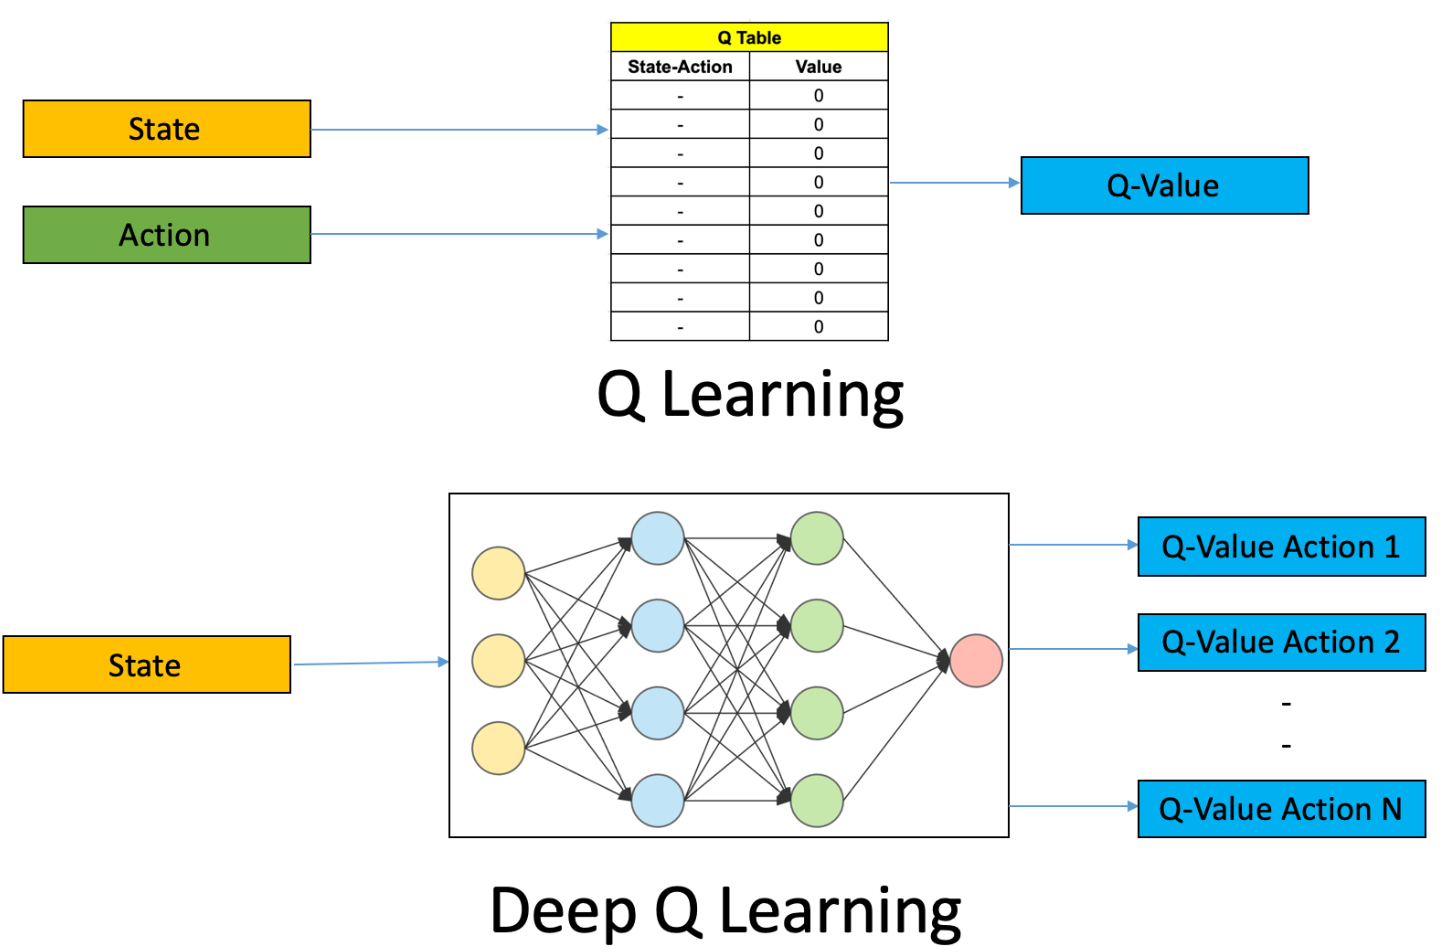

<img src="https://valohai.com/blog/reinforcement-learning-tutorial-part-1-q-learning/image4.png" width="500">
<img src="https://valohai.com/blog/reinforcement-learning-tutorial-basic-deep-q-learning/4.png" width="500">


In [2]:
!pip install gymnasium


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 15.9 MB/s eta 0:00:00


In [3]:
# Импорт необходимых библиотек
import os
import gc
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from collections import deque
import gymnasium as gym
import random
import matplotlib.pyplot as plt

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Допишите класс `ReplayMemory` для хранения переходов между состояниями.

- [ ] Проверено на семинаре

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Настройка для воспроизводимости результатов
seed = 2024
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Класс ReplayMemory для хранения переходов
class ReplayMemory:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = deque(maxlen=capacity)

    def store(self, state, action, next_state, reward, done):
        self.memory.append((state, action, next_state, reward, done))

    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)
        states, actions, next_states, rewards, dones = zip(*batch)
        return (
            torch.tensor(states, dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.long, device=device),
            torch.tensor(next_states, dtype=torch.float32, device=device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(dones, dtype=torch.bool, device=device),
        )

    def __len__(self):
        return len(self.memory)

<p class="task" id="2"></p>

2\. Допишите класс `DQN` для моделирования Q-функции.

- [ ] Проверено на семинаре

In [5]:
class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(n_observations, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)
        )

    def forward(self, x):
        return self.fc(x)

<p class="task" id="3"></p>

3\. Допишите классы `PolicyConfig` для настроек политики агента и `Policy` для реализации политики.

- [ ] Проверено на семинаре

In [7]:
from dataclasses import dataclass

In [8]:
# Настройки политики PolicyConfig
@dataclass
class PolicyConfig:
    n_observations: int
    n_actions: int
    epsilon_start: float
    epsilon_end: float
    epsilon_decay: float
    device: str = device

# Класс Policy для реализации стратегии
class Policy:
    def __init__(self, policy_cfg: PolicyConfig):
        """
        Инициализация сети политики и целевой сети.

        Args:
            policy_cfg (PolicyConfig): Конфигурация политики.
        """
        self.cfg = policy_cfg
        self.policy_network = DQN(self.cfg.n_observations, self.cfg.n_actions).to(self.cfg.device)
        self.target_network = DQN(self.cfg.n_observations, self.cfg.n_actions).to(self.cfg.device)
        self.target_network.load_state_dict(self.policy_network.state_dict())
        self.target_network.eval()
        self.epsilon = self.cfg.epsilon_start

    def sync_models(self):
        """
        Синхронизирует параметры целевой сети с основной сетью.
        """
        self.target_network.load_state_dict(self.policy_network.state_dict())

    def get_best_action(self, state, greedy=False):
        """
        Возвращает действие, выбранное на основе \(\epsilon\)-жадной стратегии или жадно.

        Args:
            state (numpy.ndarray): Текущее состояние.
            greedy (bool): Если True, выбирается лучшее действие без учёта \(\epsilon\).

        Returns:
            int: Выбранное действие.
        """
        if not greedy and np.random.rand() < self.epsilon:
            # Случайное действие (исследование)
            return np.random.randint(0, self.cfg.n_actions)

        # Преобразуем состояние в тензор
        state = torch.tensor(state, dtype=torch.float32, device=self.cfg.device).unsqueeze(0)

        # Выбираем действие на основе предсказания сети
        with torch.no_grad():
            return self.policy_network(state).argmax(dim=1).item()

    def save(self, path):
        """
        Сохраняет параметры сети на диск.

        Args:
            path (str): Путь для сохранения.
        """
        torch.save(self.policy_network.state_dict(), path)

    def load(self, path):
        """
        Загружает параметры сети с диска и синхронизирует целевую сеть.

        Args:
            path (str): Путь к сохранённой модели.
        """
        self.policy_network.load_state_dict(torch.load(path))
        self.sync_models()

<p class="task" id="4"></p>

4\. Напишите функцию `plot_metrics`, которая будет использоваться для визуализации процесса обучения: суммарной награды за каждый эпизод и максимальное значение x-координаты машины за эпизод. Для реализации можете воспользоваться `tensorboard` или любым другим удобным инструментом.

- [ ] Проверено на семинаре

In [9]:
def plot_metrics(rewards, max_positions):
    """
    Визуализация метрик обучения на отдельных графиках.

    Args:
        rewards (list): Список наград за каждый эпизод.
        max_positions (list): Список максимальных позиций за каждый эпизод.
    """
    # График наград
    plt.figure()
    plt.title("Суммарные награды за эпизод")
    plt.plot(rewards, label='Награда', marker='o', linestyle='-', markersize=3)
    plt.xlabel("Эпизоды")
    plt.ylabel("Награда")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("rewards_plot.png")  # Сохранение графика
    plt.show()

    # График максимальных позиций
    plt.figure()
    plt.title("Максимальная позиция за эпизод")
    plt.plot(max_positions, label='Макс. позиция', marker='o', linestyle='-', markersize=3, color='orange')
    plt.xlabel("Эпизоды")
    plt.ylabel("Позиция")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("max_positions_plot.png")  # Сохранение графика
    plt.show()

<p class="task" id="5"></p>

5\. Допишите классы `TrainConfig` для настроек обучения и `Trainer` для реализации процесса обучения.

- [ ] Проверено на семинаре

In [10]:
@dataclass
class TrainConfig:
    gamma: float
    learning_rate: float
    batch_size: int
    num_episodes: int
    sync_every: int

# Класс Trainer для реализации процесса обучения
class Trainer:
    def __init__(self, env, train_cfg: TrainConfig, policy: Policy):
        self.env = env
        self.cfg = train_cfg
        self.policy = policy
        self.optimizer = optim.Adam(self.policy.policy_network.parameters(), lr=self.cfg.learning_rate)
        self.memory = ReplayMemory(10000)

    def train(self):
        rewards = []
        max_positions = []

        for episode in range(self.cfg.num_episodes):
            state, _ = self.env.reset()
            total_reward = 0
            max_position = -float('inf')

            done = False
            while not done:
                action = self.policy.get_best_action(state)
                next_state, reward, done, _, _ = self.env.step(action)

                # Проверяем, достиг ли агент цели
                if next_state[0] >= 0.5:  # Условие успешного завершения
                    done = True  # Завершаем эпизод вручную
                    reward = 0  # Награда за достижение цели

                max_position = max(max_position, next_state[0])
                self.memory.store(state, action, next_state, reward, done)
                state = next_state
                total_reward = max(total_reward + reward, -200)

                if len(self.memory) >= self.cfg.batch_size:
                    self.learn()


            rewards.append(total_reward)
            max_positions.append(max_position)

            if episode % self.cfg.sync_every == 0:
                self.policy.sync_models()

            if episode % 50 == 0 or episode == self.cfg.num_episodes - 1:
                print(f"Эпизод {episode}: Награда = {total_reward}, Шагов = {len(self.memory)}, Позиция = {max_position}")



            self.policy.epsilon = max(self.policy.cfg.epsilon_end, self.policy.epsilon * self.policy.cfg.epsilon_decay)
        save_path = r"./model.pth"
        self.policy.save(save_path)
        print(f"Модель сохранена в {save_path}")
        plot_metrics(rewards, max_positions)

    def learn(self):
        states, actions, next_states, rewards, dones = self.memory.sample(self.cfg.batch_size)
        q_values = self.policy.policy_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        next_q_values = self.policy.target_network(next_states).max(1)[0]
        next_q_values[dones] = 0.0
        target_q_values = rewards + self.cfg.gamma * next_q_values
        loss = nn.functional.mse_loss(q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def test(self, num_episodes):
        """
        Выполняет тестирование модели на заданном количестве эпизодов.
        """
        self.policy.load(r"./model.pth")
        rewards = []
        for episode in range(num_episodes):
            state, _ = self.env.reset()
            total_reward = 0
            done = False
            while not done:
                action = self.policy.get_best_action(state)
                next_state, reward, done, _, _ = self.env.step(action)
                state = next_state
                total_reward += reward
            rewards.append(total_reward)
            print(f"Эпизод {episode + 1}: Награда = {total_reward}")
        return rewards

<p class="task" id="6"></p>

6\. Настройте модель для управления машиной в окружении `MountainCar-v0`. Для преобразования векторов состояний в тензоры используйте обертку `TransformObservation`. Выведите на экран график с информацией о процессе обучения. При необходимости вставьте скриншоты этих графиков.

- [ ] Проверено на семинаре

In [11]:
class Trainer:
    def __init__(self, env, train_cfg: TrainConfig, policy: Policy):
        self.env = env
        self.cfg = train_cfg
        self.policy = policy
        self.optimizer = optim.Adam(self.policy.policy_network.parameters(), lr=self.cfg.learning_rate)
        self.memory = ReplayMemory(10000)

    def learn(self):
        states, actions, next_states, rewards, dones = self.memory.sample(self.cfg.batch_size)
        q_values = self.policy.policy_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        next_q_values = self.policy.target_network(next_states).max(1)[0]
        next_q_values[dones] = 0.0
        target_q_values = rewards + self.cfg.gamma * next_q_values
        loss = nn.functional.mse_loss(q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def train(self):
        rewards = []
        max_positions = []

        for episode in range(self.cfg.num_episodes):
            state, _ = self.env.reset()
            total_reward = 0
            max_position = -float('inf')
            steps = 0
            max_steps = 200

            done = False
            while not done and steps < max_steps:
                action = self.policy.get_best_action(state)
                next_state, reward, done, _, _ = self.env.step(action)

                # Проверяем достижение цели
                if next_state[0] >= 0.5:
                    done = True
                    reward = 0  # Награда за достижение цели

                reward += 10 * abs(next_state[0] - state[0])
                max_position = max(max_position, next_state[0])

                self.memory.store(state, action, next_state, reward, done)
                state = next_state
                total_reward += reward
                steps += 1

                # Обучение каждые 10 шагов
                if len(self.memory) >= self.cfg.batch_size and steps % 10 == 0:
                    self.learn()

            rewards.append(total_reward)
            max_positions.append(max_position)

            # Синхронизация целевой сети
            if episode % self.cfg.sync_every == 0:
                self.policy.sync_models()

            # Вывод результатов
            if episode % 100 == 0:
                print(f"Эпизод {episode}: Награда = {total_reward:.2f}, Шагов = {steps}, Позиция = {max_position:.3f}")

            # Обновление epsilon
            self.policy.epsilon = max(self.policy.cfg.epsilon_end, self.policy.epsilon * self.policy.cfg.epsilon_decay)

        save_path = r"./model.pth"
        self.policy.save(save_path)
        print(f"Модель сохранена в {save_path}")
        plot_metrics(rewards, max_positions)
    def test(self, num_episodes=10):
        self.policy.load(r"./model.pth")
        print("Начало тестирования...")

        rewards = []
        for episode in range(num_episodes):
            state, _ = self.env.reset()
            total_reward = 0
            max_position = -float('inf')
            steps = 0

            done = False
            while not done:
                action = self.policy.get_best_action(state, greedy=True)
                next_state, reward, done, _, _ = self.env.step(action)

                max_position = max(max_position, next_state[0])
                state = next_state
                total_reward += reward
                steps += 1

            rewards.append(total_reward)
            print(f"Эпизод {episode + 1}: Награда = {total_reward:.2f}, Шагов = {steps}, Позиция = {max_position:.3f}")

        return rewards


<ipython-input-4-4c0539256ccb>:26: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  torch.tensor(states, dtype=torch.float32, device=device),


Эпизод 0: Награда = -186.87, Шагов = 200, Позиция = -0.376
Эпизод 100: Награда = -189.28, Шагов = 200, Позиция = -0.399
Эпизод 200: Награда = -176.07, Шагов = 200, Позиция = -0.225
Эпизод 300: Награда = -168.23, Шагов = 200, Позиция = 0.006
Эпизод 400: Награда = -185.17, Шагов = 200, Позиция = -0.223
Эпизод 500: Награда = -155.50, Шагов = 200, Позиция = 0.228
Эпизод 600: Награда = -184.34, Шагов = 200, Позиция = -0.221
Эпизод 700: Награда = -125.65, Шагов = 162, Позиция = 0.523
Эпизод 800: Награда = -101.95, Шагов = 144, Позиция = 0.503
Эпизод 900: Награда = -125.28, Шагов = 169, Позиция = 0.537
Модель сохранена в ./model.pth


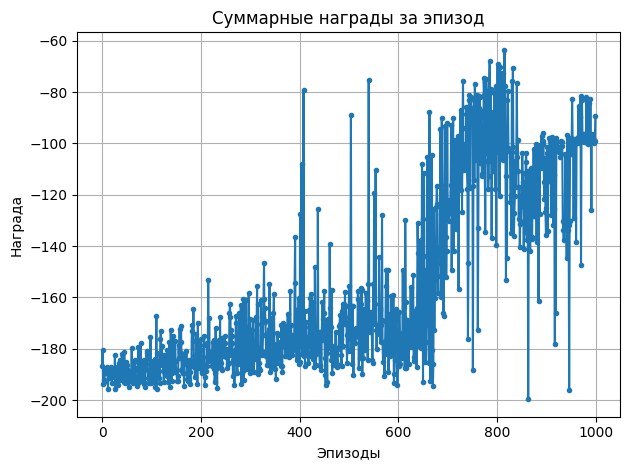

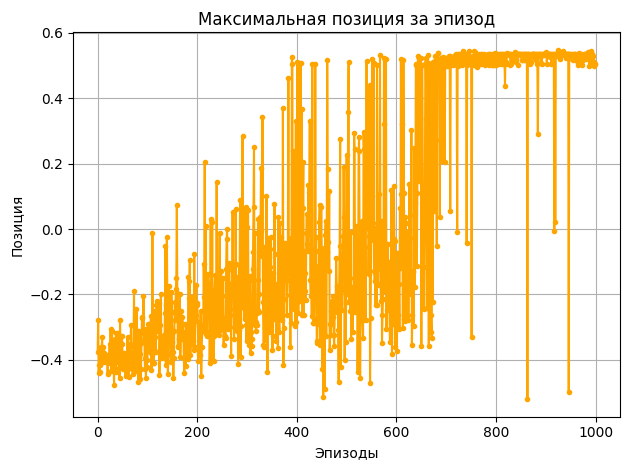

In [12]:
env = gym.make('MountainCar-v0',max_episode_steps=200)
policy_cfg = PolicyConfig(
    n_observations=env.observation_space.shape[0],
    n_actions=env.action_space.n,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995
)
train_cfg = TrainConfig(
    gamma=0.99,
    learning_rate=1e-3,
    batch_size=64,
    num_episodes=1000,
    sync_every=10
)
policy = Policy(policy_cfg)
trainer = Trainer(env, train_cfg, policy)
trainer.train()

<p class="task" id="7"></p>

7\. Загрузите состояния моделей из файлов, которые были получены в процессе обучения. Создайте окружение и сыграйте эпизод, используя стратегию, выведенную из обученной Q-функции.

- [ ] Проверено на семинаре

In [13]:
trainer.test(num_episodes=10)

<ipython-input-8-4266f7b32d3e>:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.policy_network.load_state_dict(torch.load(path))


Начало тестирования...
Эпизод 1: Награда = -109.00, Шагов = 109, Позиция = 0.520
Эпизод 2: Награда = -140.00, Шагов = 140, Позиция = 0.537
Эпизод 3: Награда = -130.00, Шагов = 130, Позиция = 0.502
Эпизод 4: Награда = -109.00, Шагов = 109, Позиция = 0.520
Эпизод 5: Награда = -141.00, Шагов = 141, Позиция = 0.537
Эпизод 6: Награда = -134.00, Шагов = 134, Позиция = 0.510
Эпизод 7: Награда = -165.00, Шагов = 165, Позиция = 0.537
Эпизод 8: Награда = -141.00, Шагов = 141, Позиция = 0.527
Эпизод 9: Награда = -111.00, Шагов = 111, Позиция = 0.511
Эпизод 10: Награда = -138.00, Шагов = 138, Позиция = 0.513


[-109.0,
 -140.0,
 -130.0,
 -109.0,
 -141.0,
 -134.0,
 -165.0,
 -141.0,
 -111.0,
 -138.0]

## Обратная связь
- [ ] Хочу получить обратную связь по решению